# Neurons notebook

Assumes that sessions have been sorted and we import the dataframe that contains all the good cells with the spike times

Migrating from aggregate_neurons.py

In [ ]:
import sys
from pathlib import Path

# Use __file__ if it exists (script), otherwise use the current working directory (notebook)
try:
    THIS_FILE = Path(__file__).resolve()
except NameError:
    THIS_FILE = Path.cwd() / "neurons.ipynb"

PROJECT_ROOT = THIS_FILE.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root on sys.path:", PROJECT_ROOT)

import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import zscore
from scipy.signal import savgol_filter
import statsmodels.api as sm
from scipy.signal import find_peaks, correlate
from itertools import chain
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from scipy.ndimage import gaussian_filter1d


from ratcode.config.paths import PATH_STORE_PICKLES, DROPBOX_TASK_PATH, PATH_DANEURONS_ANALYSIS, PATH_DATAFRAMES, PATH_EPHYS_ANALYSIS
from ratcode.common.logging import determine_experiment
from ratcode.common.colorcodes import *
from ratcode.behavior import change_point
from ratcode.photometry.photometry import drop_nan_rows_in_matrix, get_prediction, quantile_regression, signal2eventsnippets, find_poly, segment_and_fit_function, butter_filter, mask_jumps, make_continuous, query_and_compute_snippets, plot_snippets
from ratcode.ephys.neurons import get_psths_across_cells, align_spikes_to_ttl, compute_FR, load_ibl_sorter, determine_cell_type, produce_neuron_fig, produce_mega_neuron_fig, compute_zscore, get_psths_smooth, half_gaussian_kernel, do_PCA, get_PCA_windows, sort_index_order, filter_common_cells
from ratcode.common.dataframe import group_and_listify
from ratcode.common.time import convert_date_bonsai, convert_timestamp
from ratcode.common.math import drop_nans_matrix
from ratcode.common.colorcodes import FI_order, color_FI_blocks, rwd_order, color_rwd_blocks
from ratcode.common.plotting import remove_legend, add_3d_line_w_start_matplotlib, add_3d_line_w_start

from ratcode.init import setup

setup()

Project root on sys.path: d:\Learning Lab Dropbox\Learning Lab Team Folder\Patlab protocols\Code\Python\SF\rats_ficlickrwd


In [2]:
PATH_SAVE_EPHYS_AGG_FIGS = rf'{PATH_EPHYS_ANALYSIS}\aggregated_ephys'


## this should be saved as a dictionary somewhere, and imported
dates_Ruthenium = ['260219',
 '260220',
 #'260223', ## bad bhv - viv watered them
 '260224',
 '260225',
 '260226',
 '260227',
 '260228',
 '260303',
 '260304',
 '260305',
 '260306',
 '260308',
 '260310',
 '260311',
 '260312',
 '260318',
 '260319',
 '260320',
 '260323',
 '260324',
 '260325',
 '260327',
 '260330']

dates_Palladium = ['260218',
 '260219',
 '260220',
 #'260223', ## bad bhv - viv watered them
 '260224',
 '260225',
 '260226',
 '260227',
 '260302',
 '260303',
 '260304',
 '260306',
 '260308',
 '260309',
 '260310',
 '260311',
 '260312',
 '260318',
 #'260319',
 '260319', ## session 260319b is usable! 36mins with DA; but for now let's leave it out
 #'260320',
 #'260320',
 '260323',
 #'260324' ## only two blocks
 '260327',
 '260330']

In [3]:
animal = 'Ruthenium'

if animal == 'Ruthenium':
    dates = dates_Ruthenium
elif animal == 'Palladium':
    dates = dates_Palladium
else:
    dates = [] 

aggregated_neuronsdf = pd.read_pickle(rf'{PATH_EPHYS_ANALYSIS}\{animal}_aggregated_neuronsdf.pkl')

blocksdf = pd.read_pickle(rf'{PATH_DATAFRAMES}\blocksdf_Ruthenium_Palladium.pkl')

aggregated_syncdf = pd.read_pickle(rf'{PATH_DATAFRAMES}\{animal}_aggregated_syncdf.pkl')


Select the cells to use, based on quality

In [4]:
cells_to_use_neurons = []
dates_neurons = dates

#dates_to_consider = blocksdf.query(f'date == {ephys_dates_dict[animal]} and animal == "{animal}" and experiment != "c"').date.unique()
#ephys_dates_dict[animal]
for date in dates_neurons:
    cells_to_use_neurons.append(
        aggregated_neuronsdf.query(f'date == "{date}" and cell_type == "MSN" and (SF == "good" or SF == "ok") and fr >=.2').get(['animal', 'date', 'cluster_id']).itertuples(index=False, name=None))

cells_to_use_neurons = list(chain.from_iterable(cells_to_use_neurons))

some redefinitions, for consistency

In [5]:
aggregated_syncdf['npx_trial_start'] = aggregated_syncdf['npx_time']

get_psths_across_cells looks at spike times and aligns them to some event in a window [pre_time, post_time], outputing the psths (smooth or not) as well as the corresponding cells. Shape of psths is (cells, time)

The next few cells are just implementing that function across all experimental conditions (varying FIs and varying rwds)

In [6]:
_, _, FI15a_psths_smooth, cells15a, _ = get_psths_across_cells(
    aggregated_neuronsdf,
    aggregated_syncdf.query('experiment == "a" and FI == 15'),
    cells_to_use_neurons,'npx_trial_start',
    pre_time = 0, post_time = 15, quiet = True)

_, _, FI30a_psths_smooth, cells30a, _ = get_psths_across_cells(
    aggregated_neuronsdf,
    aggregated_syncdf.query('experiment == "a" and FI == 30'),
    cells_to_use_neurons,'npx_trial_start',
    pre_time = 0, post_time = 30, quiet = True)

_, _, FI60a_psths_smooth, cells60a, _ = get_psths_across_cells(
    aggregated_neuronsdf,
    aggregated_syncdf.query('experiment == "a" and FI == 60'),
    cells_to_use_neurons,'npx_trial_start',
    pre_time = 0, post_time = 60, quiet = True)

In [7]:
_, _, FI15b_psths_smooth, cells15b, _ = get_psths_across_cells(
    aggregated_neuronsdf,
    aggregated_syncdf.query('experiment == "b" and FI == 15'),
    cells_to_use_neurons,'npx_trial_start',
    pre_time = 0, post_time = 15, quiet = True)

_, _, FI30b_psths_smooth, cells30b, _ = get_psths_across_cells(
    aggregated_neuronsdf,
    aggregated_syncdf.query('experiment == "b" and FI == 30'),
    cells_to_use_neurons,'npx_trial_start',
    pre_time = 0, post_time = 30, quiet = True)

_, _, FI60b_psths_smooth, cells60b, _ = get_psths_across_cells(
    aggregated_neuronsdf,
    aggregated_syncdf.query('experiment == "b" and FI == 60'),
    cells_to_use_neurons,'npx_trial_start',
    pre_time = 0, post_time = 60, quiet = True)

In [8]:
_, _, rwd7c_psths_smooth, cells7c, _ = get_psths_across_cells(
    aggregated_neuronsdf,
    aggregated_syncdf.query('experiment == "c" and n_protocols == 7'),
    cells_to_use_neurons,'npx_trial_start',
    pre_time = 0, post_time = 30, quiet = True)

_, _, rwd14c_psths_smooth, cells14c, _ = get_psths_across_cells(
    aggregated_neuronsdf,
    aggregated_syncdf.query('experiment == "c" and n_protocols == 14'),
    cells_to_use_neurons,'npx_trial_start',
    pre_time = 0, post_time = 30, quiet = True)

_, _, rwd28c_psths_smooth, cells28c, _ = get_psths_across_cells(
    aggregated_neuronsdf,
    aggregated_syncdf.query('experiment == "c" and n_protocols == 28'),
    cells_to_use_neurons,'npx_trial_start',
    pre_time = 0, post_time = 30, quiet = True)

This is the basis of the "tiling"/ scalar timing at the neurons level. Say we want to look at how a neural population spans a time interval, we can sort the cells by their "peak activity" in said interval. Now, this "peak activity" sorting doesn't correspond to actually finding the peak of the PSTH and then sorting, but rather by projecting all cells activities in their first principal components (PCs) and then sorting. This method is properly described in the ODORS paper, but the intuition behind it is that if you have some "clock-like" signature, the loadings in the first PCs can serve as sorting and this is more robust to noise than plain peak sorting.

I packaged the PCA and index order according to the loadings in the function `do_PCA`. Let's use it for an example interval, say FI30, on experimental condition a (varying FI, fixed reward).

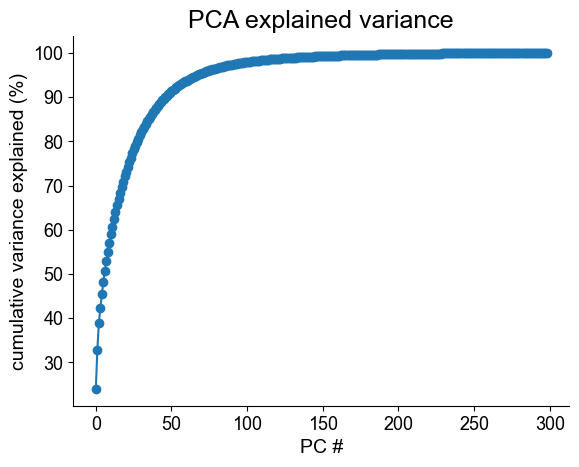

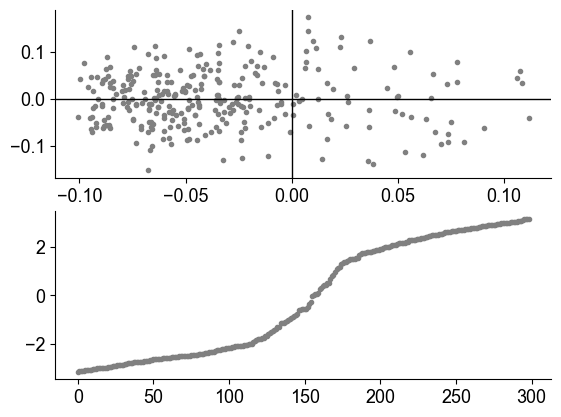

<Figure size 640x480 with 0 Axes>

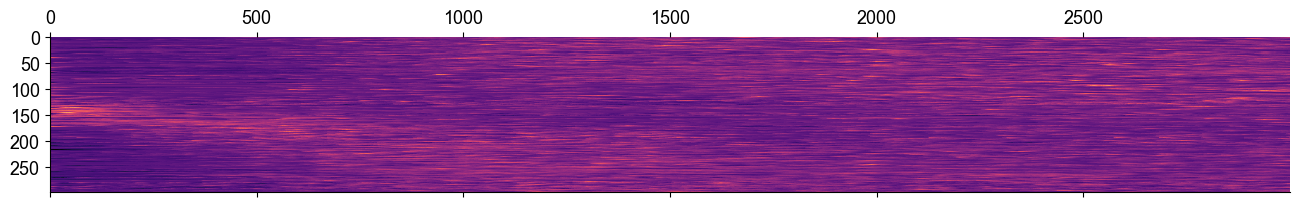

In [9]:
index_order, loadings, PC_space = do_PCA(zscore(FI30a_psths_smooth, axis = 1))

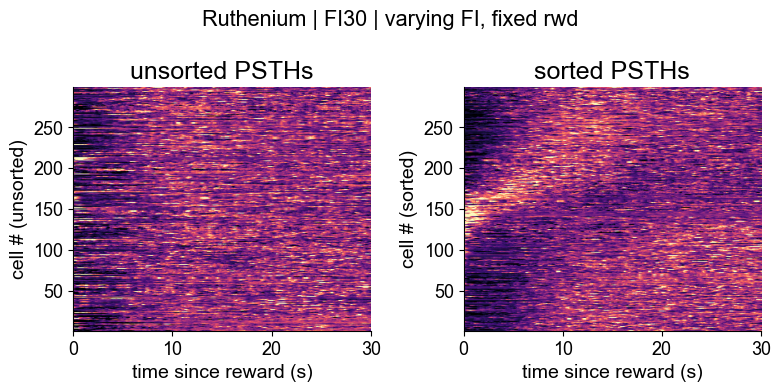

In [10]:
fig, axs = plt.subplots(1,2, figsize = (8,4), tight_layout = True)

FI30a_psths_smooth_z = zscore(FI30a_psths_smooth, axis = 1)
vmin, vmax = np.quantile(FI30a_psths_smooth_z, [.01,.99])
axs[0].imshow(FI30a_psths_smooth_z, aspect = 'auto',
              vmin = vmin, vmax = vmax, cmap = 'magma', origin = 'lower',
              extent = [0,30, 1, len(FI30a_psths_smooth_z)])
axs[1].imshow(FI30a_psths_smooth_z[index_order], aspect = 'auto',
              vmin = vmin, vmax = vmax, cmap = 'magma', origin = 'lower',
              extent = [0,30, 1, len(FI30a_psths_smooth_z)])

axs[0].set_title('unsorted PSTHs')
axs[1].set_title('sorted PSTHs')
axs[0].set_ylabel('cell # (unsorted)')
axs[1].set_ylabel('cell # (sorted)')

[axs[ii].set_xlabel('time since reward (s)') for ii in range(2)]

plt.suptitle(f'{animal} | FI30 | varying FI, fixed rwd')

plt.show()

This shows that the population in FI30 traces a non-repeating pattern within the trial duration, but we did this only for one of the FIs. For the purposes of scalar timing, this is insufficient, because it doesn't show whether the neurons adapt their relative position in the interval to different FIs. There are multiple ways to show/ test for that: 

1. do this approach separately for each of the FIs and then compare how similar their position in the interval is (in particular look at how similar the angular position in PC1-PC2 space is across different FIs). This is what was done in GUGA PAPER

2. do this approach for one of the intervals and then use that index order as a "standard" for the remaining intervals. So far we haven't done this, but could -- would have to decide on some metric of how to assess quality of sorting for the non-standard intervals though

3. concatenate all the intervals together (row-wise) and apply the approach. This effectively forces the PCA to look for dimensions that are good to explain variance across the multiple intervals (because they are concatenated together). This approach doesn't guarantee that the "optimal order" is found for each interval, but rather that the optimal order is found for the set of the 3 intervals. This method needs to be complemented by something else so that one is able to make claims about how (many) cells preserve their ordinal position in the interval (e.g. by computing scaling factors or by using some metric like the angular position similarity in Guga) - c.f. with the COOLING PAPER (this is what they do)

We will be using the 3rd method here, and work with all cells (MSNs) -- for paper purposes one would probably claim scalar timing with cells that maintain their ordinal position and then show all cells in the supplementary

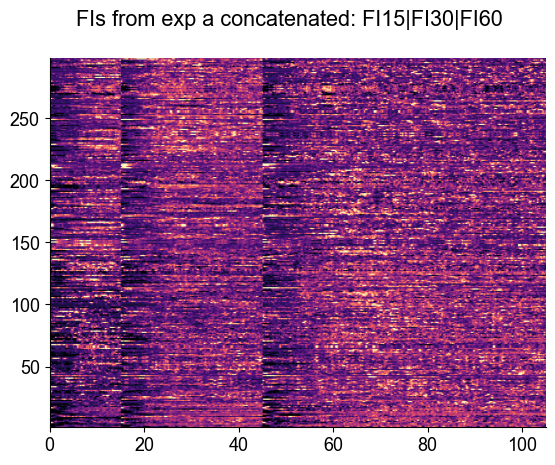

In [11]:
FIconcat_a = np.concatenate([FI15a_psths_smooth, FI30a_psths_smooth, FI60a_psths_smooth], axis = 1)


FIconcat_a_z = zscore(FIconcat_a, axis = 1)
vmin, vmax = np.quantile(FIconcat_a_z, [.01,.99])
plt.imshow(FIconcat_a_z, aspect = 'auto',
              vmin = vmin, vmax = vmax, cmap = 'magma', origin = 'lower',
              extent = [0,15+30+60, 1, len(FI30a_psths_smooth_z)])
plt.suptitle('FIs from exp a concatenated: FI15|FI30|FI60')
plt.show()

Fig above is the example of all FIs from experiment a concatenated: each row is a cell, with the correspondence:
- 0 to 15 s: FI15
- 15 to 45 s: FI30
- 45 to 105 s: FI60

There's not much of a structure to detect by eye, but the tiling will become clear in the next fig. Notice the clear vertical interruptions between the different FIs.

And now we sort using the `do_PCA` function

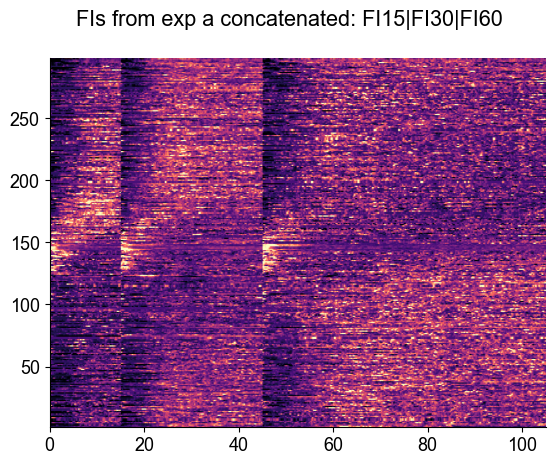

In [12]:
index_order_a, loadings_a, PC_space_a = do_PCA(FIconcat_a_z, quiet=True)

vmin, vmax = np.quantile(FIconcat_a_z, [.01,.99])
plt.imshow(FIconcat_a_z[index_order_a], aspect = 'auto',
              vmin = vmin, vmax = vmax, cmap = 'magma', origin = 'lower',
              extent = [0,15+30+60, 1, len(FI30a_psths_smooth_z)])
plt.suptitle('FIs from exp a concatenated: FI15|FI30|FI60')
plt.show()

Something you probably noticed by now is that the `index_order` parameter gives an order that tiles the population, but doesn't really set the first cell to be the one that starts the pattern. Indeed, this algorithm works in angular position space and so it's up to us to "arbitrate" the zero. We don't have a systematic way of doing that in the lab, and we simply do it by eye. To make it easier, I use a little helper function `sort_index_order`, in which the user decides the cell number that should be set as the zero of the tiling

array([ 30, 259, 241, 182, 134, 145,  32,  43, 137, 192,  89,  90,  69,
       212, 176,  55, 218, 209, 151,  93, 171,  22, 135, 248, 211, 228,
       112, 170, 210,  86, 197, 149, 104,  41, 147, 292,  66,  77, 180,
       270, 198, 297, 146, 265, 126,  39, 143, 138,   8, 202, 156, 282,
       293, 227, 189, 284, 271, 233, 148, 275, 122, 150, 165, 232, 177,
       115, 249, 201, 119, 296, 276, 238, 214, 225, 229, 236, 251, 191,
       217, 174, 109, 273, 224, 277, 240, 250,  46, 179, 131, 128, 290,
       222, 267,  72, 130, 274, 239,  24, 272, 264,  52, 246, 163, 226,
       287, 245, 289, 295, 242,  80, 106, 162,  65,  64, 266, 221,  50,
       223,  63, 254, 255, 169, 168, 252, 160, 258,  23, 105, 157, 184,
       195, 278, 230,  51, 262, 268, 200, 257, 281, 140, 231, 261,  95,
       219, 186, 152, 280, 127, 256, 114, 175,  13, 178, 100,  67, 185,
       220, 155, 247, 161, 153, 294,  17, 118, 234, 142,   9, 187,  29,
        18,  57,  25,   5, 194, 243,  12,  11, 193, 196, 141,  5

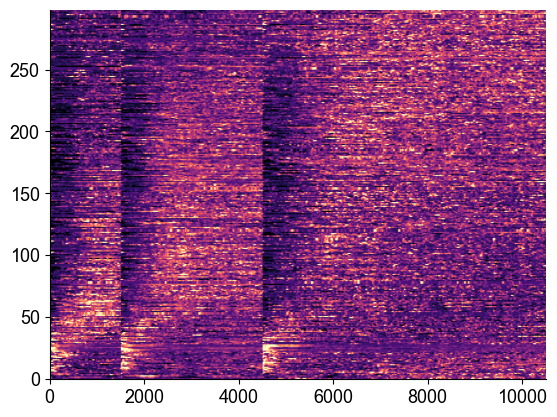

In [18]:
sort_index_order(120,index_order_a, FIconcat_a_z)


Now let's do the same for the other 2 experimental conditions

In [21]:
FIconcat_b = np.concatenate([FI15b_psths_smooth, FI30b_psths_smooth, FI60b_psths_smooth], axis = 1)
FIconcat_c = np.concatenate([rwd7c_psths_smooth, rwd14c_psths_smooth, rwd28c_psths_smooth], axis = 1)
# yes, I know FIconcat_c is a nonsense name because in exp c the FI doesnt change, but I kept it like this for consistency reasons with the other two

FIconcat_b_z = zscore(FIconcat_b, axis = 1)
FIconcat_c_z = zscore(FIconcat_c, axis = 1)

index_order_b, loadings_b, PC_space_b = do_PCA(FIconcat_b_z, quiet = True)
index_order_c, loadings_c, PC_space_c = do_PCA(FIconcat_c_z, quiet = True)

Text(0.5, 0.98, 'Ruthenium | aggregate across days | tiling | MSNs across experimental conditions')

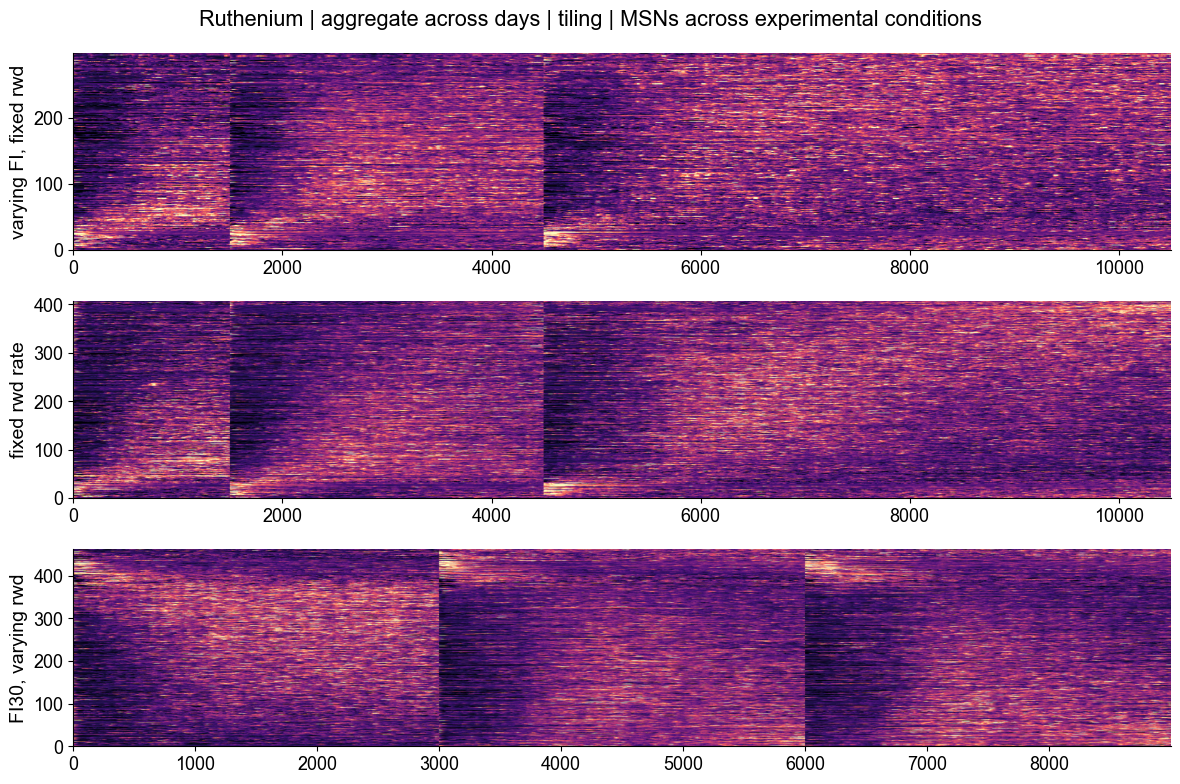

In [ ]:
fig, axs = plt.subplots(3,tight_layout = True, figsize = (12,8))
# feel free to play around with these numbers to see how it affects the visual tiling
# sort_index_order(0, ....) is the same as plotting the original order from do_PCA()
sort_index_order(120,index_order_a, FIconcat_a_z, axs[0])
sort_index_order(170,index_order_b, FIconcat_b_z, axs[1])
sort_index_order(260,index_order_c, FIconcat_c_z, axs[2])

axs[0].set_ylabel('varying FI, fixed rwd')
axs[1].set_ylabel('fixed rwd rate')
axs[2].set_ylabel('FI30, varying rwd')

figtitle = f'{animal} | aggregate across days | tiling | MSNs across experimental conditions'
fig.suptitle(figtitle)

Note that it is a bit stupid to talk about scalar timing in the case of experiment c (the last row), because effectively the FI doesn't change, so there is no temporal adapatation. Nonetheless, I leave it here plotted with the order for completeness sake -- and as we will see right away, the PCA approach is useful/ would be needed for plotting the neural trajectories.

Here these are the "raw" trajectories without smoothing -- what one usually sees in papers/ in lab meetings are smoothed trajectories

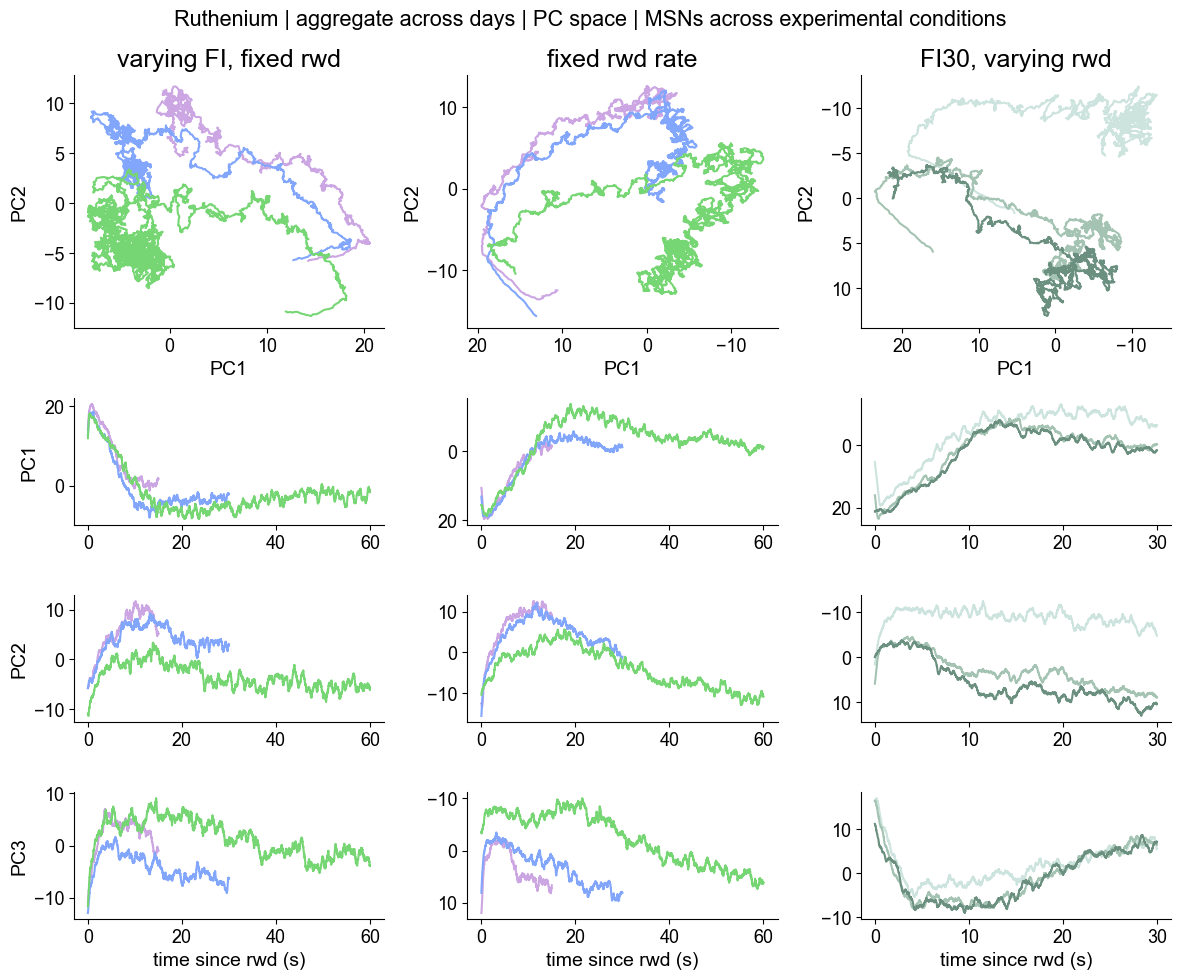

In [71]:
fig, axs = plt.subplots(4,3,tight_layout = True, figsize = (12,10), height_ratios=[2,1,1,1])

t_15 = np.arange(0,15,.01)
t_30 = np.arange(0,30,.01)
t_60 = np.arange(0,60,.01)

axs[0,0].plot(PC_space_a[:1500,0], PC_space_a[:1500,1], color = color_FI_blocks[0])
axs[0,0].plot(PC_space_a[1500:4500,0], PC_space_a[1500:4500,1], color = color_FI_blocks[1])
axs[0,0].plot(PC_space_a[4500:,0], PC_space_a[4500:,1], color = color_FI_blocks[2])

axs[0,1].plot(PC_space_b[:1500,0], PC_space_b[:1500,1], color = color_FI_blocks[0])
axs[0,1].plot(PC_space_b[1500:4500,0], PC_space_b[1500:4500,1], color = color_FI_blocks[1])
axs[0,1].plot(PC_space_b[4500:,0], PC_space_b[4500:,1], color = color_FI_blocks[2])

axs[0,2].plot(PC_space_c[:3000,0], PC_space_c[:3000,1], color = color_rwd_blocks[0])
axs[0,2].plot(PC_space_c[3000:6000,0], PC_space_c[3000:6000,1], color = color_rwd_blocks[1])
axs[0,2].plot(PC_space_c[6000:,0], PC_space_c[6000:,1], color = color_rwd_blocks[2])

for ii in range(3):
    axs[ii+1,0].plot(t_15, PC_space_a[:1500,ii], color = color_FI_blocks[0])
    axs[ii+1,0].plot(t_30, PC_space_a[1500:4500,ii], color = color_FI_blocks[1])
    axs[ii+1,0].plot(t_60, PC_space_a[4500:,ii], color = color_FI_blocks[2])

    axs[ii+1,1].plot(t_15, PC_space_b[:1500,ii], color = color_FI_blocks[0])
    axs[ii+1,1].plot(t_30, PC_space_b[1500:4500,ii], color = color_FI_blocks[1])
    axs[ii+1,1].plot(t_60, PC_space_b[4500:,ii], color = color_FI_blocks[2])

    axs[ii+1,2].plot(t_30, PC_space_c[:3000,ii], color = color_rwd_blocks[0])
    axs[ii+1,2].plot(t_30, PC_space_c[3000:6000,ii], color = color_rwd_blocks[1])
    axs[ii+1,2].plot(t_30, PC_space_c[6000:,ii], color = color_rwd_blocks[2])


for ii in range(3):
    axs[0,ii].set_ylabel('PC2')
    axs[0,ii].set_xlabel('PC1')

axs[1,0].set_ylabel('PC1')
axs[2,0].set_ylabel('PC2')
axs[3,0].set_ylabel('PC3')

[axs[3,ii].set_xlabel('time since rwd (s)') for ii in range(3)]

axs[0,0].set_title('varying FI, fixed rwd')
axs[0,1].set_title('fixed rwd rate')
axs[0,2].set_title('FI30, varying rwd')


## invert axis to compare the shape (PCA is invariant to sign)
axs[0,1].invert_xaxis()
axs[0,2].invert_xaxis()
axs[0,2].invert_yaxis()

axs[1,1].invert_yaxis()
axs[1,2].invert_yaxis()

axs[2,2].invert_yaxis()

axs[3,1].invert_yaxis()


figtitle = f'{animal} | aggregate across days | PC space | MSNs across experimental conditions'
fig.suptitle(figtitle)
fig.savefig(f'{PATH_SAVE_EPHYS_AGG_FIGS}/{figtitle.replace("|", "_")}.png', dpi = 300)

In [70]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Create the figure layout
fig = make_subplots(rows=1, cols=3, subplot_titles=('exp a', 'exp b', 'exp c'),
                    specs=[[{'type': 'scene'}, {'type': 'scene'}, {'type': 'scene'}]])

# 2. Add traces to specific rows/cols
#fig.add_trace(
#    go.Scatter(x=[1, 2, 3], y=[4, 5, 6]),
#    row=1, col=1
#)

#fig.add_trace(
#    go.Bar(x=[1, 2, 3], y=[2, 3, 5]),
#    row=1, col=2
#)

for jj, FI in enumerate(FI_order):  
    window_start = 0 if jj == 0 else window_end
    window_end = window_start + FI*100

    ## exp a    
    PC_traces = PC_space_a[window_start:window_end]
    
    add_3d_line_w_start(fig, gaussian_filter1d(PC_traces, sigma=10, axis = 0),
                        color_FI_blocks[jj],f'FI{FI}', row = 1, col = 1)

    ## exp b
    PC_traces = PC_space_b[window_start:window_end]

    add_3d_line_w_start(fig, gaussian_filter1d(PC_traces, sigma=10, axis = 0),
                        color_FI_blocks[jj],f'FI{FI}', row = 1, col = 2)

## exp c
for jj, rwd in enumerate(rwd_order):  
    window_start = 0 if jj == 0 else window_end
    window_end = window_start + 30*100

    ## exp a    
    PC_traces = PC_space_c[window_start:window_end]
    
    add_3d_line_w_start(fig, gaussian_filter1d(PC_traces, sigma=10, axis = 0),
                        color_rwd_blocks[jj],f'rwd{rwd}', row = 1, col = 3)

figtitle = f"{animal} | neural trajectories across the 3 experimental conditions"

fig.update_layout(
    height=450,   # 400px for the plot + 50px for titles/margins
    width=1300,   # Roughly 400px per plot + some spacing
    margin=dict(t=50, b=20, l=20, r=20),
    showlegend=True,
    title=dict(
        text=figtitle,
        x=0.5,           # Centers the title (0 = left, 1 = right)
        xanchor='center',
        font=dict(size=16)
    )
)

fig.update_scenes(
    aspectmode='cube' 
)

fig.show()
fig.write_html(f'{PATH_SAVE_EPHYS_AGG_FIGS}/{figtitle.replace('|', '_')}.html')

There is still no clear conclusion about what the shape of these trajectories means. Initially we had an hypothesis that different FIs under the same rwd (exp a) could translate to the same neural trajectory (being traversed at different speeds), whereas differences in rwd (exp c) would translate into gain-like modifications (e.g. eccentricity) to the trajectories